In [1]:
%pip install torch torchvision gradio opencv-python matplotlib seaborn pandas numpy kagglehub


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

/Users/makhmud.lp/Codes All/torch-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%mkdir -p ~/.kaggle
# Move the downloaded file there
%mv kaggle.json ~/.kaggle/kaggle.json



mv: kaggle.json: No such file or directory


In [4]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100%|██████████████████████████████████████| 60.3M/60.3M [00:05<00:00, 11.7MB/s]



In [5]:
import os
import zipfile

from pathlib import Path

import requests

In [ ]:

%mv fer2013.zip data
target_file = "data/fer2013.zip"
target_path="data"
# Unzip pizza, steak, sushi data
with zipfile.ZipFile(target_file, "r") as zip_ref:
    zip_ref.extractall(target_path)
%rm target_file


mv: fer2013.zip: No such file or directory
rm: target_path: No such file or directory


=== Dataset Distribution ===
angry     : 3995 images
disgust   : 436 images
fear      : 4097 images
happy     : 7215 images
neutral   : 4965 images
sad       : 4830 images
surprise  : 3171 images

Total training images: 28709


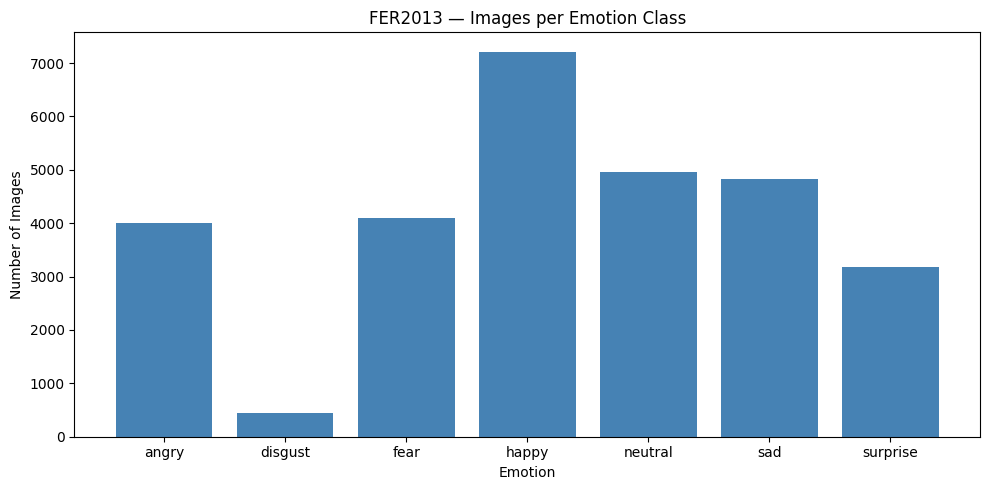

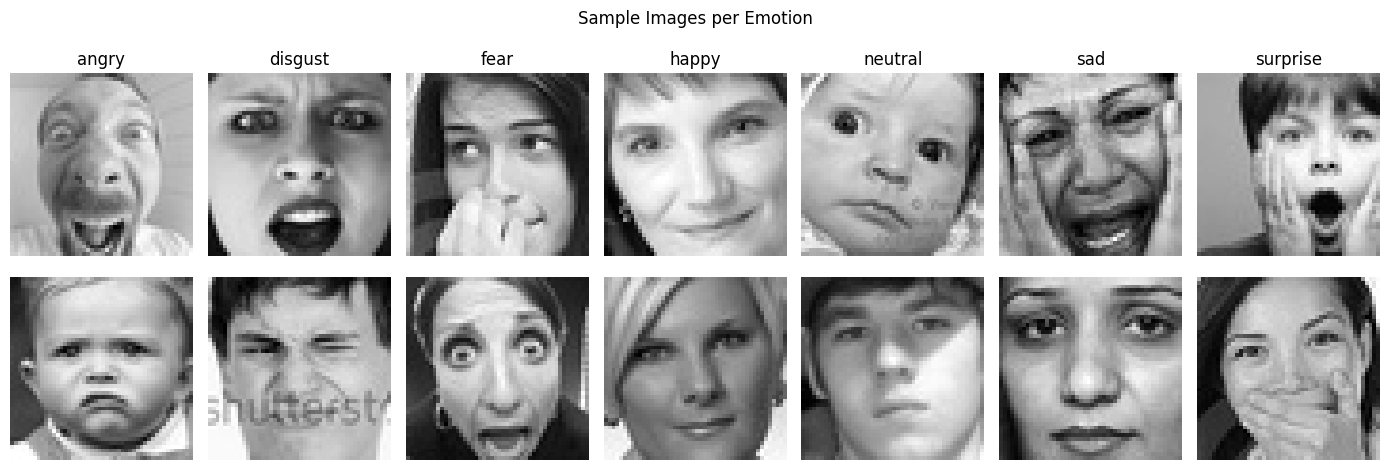

In [8]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_dir = "data/train"
emotions = os.listdir(data_dir)

# Count images per class
print("=== Dataset Distribution ===")
counts = {}
for emotion in sorted(emotions):
    path = os.path.join(data_dir, emotion)
    if os.path.isdir(path):
        n = len(os.listdir(path))
        counts[emotion] = n
        print(f"{emotion:10s}: {n} images")

print(f"\nTotal training images: {sum(counts.values())}")

# Plot distribution
plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color="steelblue")
plt.title("FER2013 — Images per Emotion Class")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

# Show sample images
fig, axes = plt.subplots(2, 7, figsize=(14, 5))
for i, emotion in enumerate(sorted(counts.keys())):
    folder = os.path.join(data_dir, emotion)
    sample = os.path.join(folder, os.listdir(folder)[0])
    img = mpimg.imread(sample)
    axes[0][i].imshow(img, cmap="gray")
    axes[0][i].set_title(emotion)
    axes[0][i].axis("off")

    sample2 = os.path.join(folder, os.listdir(folder)[1])
    img2 = mpimg.imread(sample2)
    axes[1][i].imshow(img2, cmap="gray")
    axes[1][i].axis("off")

plt.suptitle("Sample Images per Emotion")
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

In [9]:
!python dataset.py

In [10]:
import torch
from models.cnn import EmotionCNN



# Simulate a batch of 8 grayscale 48x48 images
dummy_input = torch.randn(8, 1, 48, 48)

model = EmotionCNN(num_classes=7)

# Forward pass
output = model(dummy_input)

print(f"Input shape:  {dummy_input.shape}")   # [8, 1, 48, 48]
print(f"Output shape: {output.shape}")        # [8, 7]
print(f"Output sample:\n{output[0]}")         # 7 raw scores for first image

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

Input shape:  torch.Size([8, 1, 48, 48])
Output shape: torch.Size([8, 7])
Output sample:
tensor([-0.7928, -0.4251, -0.2821,  0.1512,  0.0754,  0.1890,  0.5548],
       grad_fn=<SelectBackward0>)

Total parameters:     684,743
Trainable parameters: 684,743


In [ ]:
print(model)

EmotionCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inpl

In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

# 7 emotion classes
EMOTIONS = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
EMOTION_TO_IDX = {emotion: idx for idx, emotion in enumerate(EMOTIONS)}

class FERDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        """
        root_dir: path to data/ folder
        split: "train" or "test"
        transform: torchvision transforms
        """
        self.samples = []   # list of (image_path, label) tuples
        self.transform = transform

        split_dir = os.path.join(root_dir, split)

        # Walk through each emotion folder
        for emotion in EMOTIONS:
            emotion_dir = os.path.join(split_dir, emotion)
            if not os.path.isdir(emotion_dir):
                continue
            label = EMOTION_TO_IDX[emotion]
            for img_file in os.listdir(emotion_dir):
                if img_file.endswith((".jpg", ".png", ".jpeg")):
                    img_path = os.path.join(emotion_dir, img_file)
                    self.samples.append((img_path, label))

        print(f"[{split}] Loaded {len(self.samples)} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # Load as grayscale (FER2013 images are grayscale)
        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, label


# --- Transforms ---

# Training: augmentation to make model more robust
train_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),        # flip face left/right
    transforms.RandomRotation(10),            # slight rotation
    transforms.ColorJitter(brightness=0.2,    # slight brightness change
                           contrast=0.2),
    transforms.ToTensor(),                    # convert to tensor [0,1]
    transforms.Normalize(mean=[0.5],          # normalize grayscale
                         std=[0.5])
])

# Testing: no augmentation, just normalize
test_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from models.cnn import EmotionCNN
import os

# ============================================================
# CONFIG — change these to experiment
# ============================================================
BATCH_SIZE  = 64
EPOCHS      = 30
LR          = 0.001
DEVICE      = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
SAVE_PATH   = "models/best_model.pth"

print(f"Training on: {DEVICE}")

# ============================================================
# DATASET & DATALOADER
# ============================================================
train_dataset = FERDataset("data", split="train", transform=train_transform)
test_dataset  = FERDataset("data", split="test",  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ============================================================
# CLASS WEIGHTS — fix imbalance (disgust has very few samples)
# ============================================================
samples_per_class = np.array([
    3995,   # angry
     436,   # disgust
    4097,   # fear
    7215,   # happy
    4965,   # neutral
    4830,   # sad
    3171,   # surprise
])

total = samples_per_class.sum()
num_classes = len(samples_per_class)

# Rare classes get higher weight
weights = total / (num_classes * samples_per_class)
weights = torch.FloatTensor(weights).to(DEVICE)

print(f"Class weights: {weights.cpu().numpy().round(2)}")

# ============================================================
# MODEL, LOSS, OPTIMIZER
# ============================================================
model     = EmotionCNN(num_classes=7).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Learning rate scheduler — reduce LR when validation stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.5
)

# ============================================================
# TRAINING FUNCTIONS
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()   # training mode — dropout ON, batchnorm uses batch stats
    
    total_loss    = 0
    correct       = 0
    total_samples = 0

    for batch_idx, (images, labels) in enumerate(loader):
        # Move data to device (MPS/CPU)
        images = images.to(device)
        labels = labels.to(device)

        # --- 4 steps of learning ---
        outputs = model(images)                  # 1. forward pass
        loss    = criterion(outputs, labels)     # 2. calculate loss

        optimizer.zero_grad()                    # 3a. clear old gradients
        loss.backward()                          # 3b. compute new gradients
        optimizer.step()                         # 4. update weights

        # --- Bookkeeping ---
        total_loss += loss.item()

        # Get predicted class (highest score)
        predicted = outputs.argmax(dim=1)
        correct       += (predicted == labels).sum().item()
        total_samples += labels.size(0)

        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} "
                  f"| Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    accuracy = correct / total_samples * 100
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()    # eval mode — dropout OFF, batchnorm uses running stats
    
    total_loss    = 0
    correct       = 0
    total_samples = 0

    with torch.no_grad():   # no gradient computation needed for evaluation
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs   = model(images)
            loss      = criterion(outputs, labels)

            total_loss    += loss.item()
            predicted      = outputs.argmax(dim=1)
            correct       += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total_samples * 100
    return avg_loss, accuracy


# ============================================================
# MAIN TRAINING LOOP
# ============================================================
best_val_accuracy = 0.0
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   []
}

print(f"\n{'='*55}")
print(f"  Starting training for {EPOCHS} epochs")
print(f"{'='*55}\n")

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")

    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    # Evaluate
    val_loss, val_acc = evaluate(
        model, test_loader, criterion, DEVICE
    )

    # Update learning rate scheduler
    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save({
            "epoch":      epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_accuracy": val_acc,
        }, SAVE_PATH)
        print(f"  ✅ New best model saved! Val Acc: {val_acc:.2f}%")

    # Store history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Best Val Acc so far: {best_val_accuracy:.2f}%\n")

print(f"Training complete! Best validation accuracy: {best_val_accuracy:.2f}%")

Training on: mps
[train] Loaded 28709 images
[test] Loaded 7178 images
Class weights: [1.03 9.41 1.   0.57 0.83 0.85 1.29]

  Starting training for 30 epochs

Epoch 1/30
  Batch 100/449 | Loss: 1.9112
  Batch 200/449 | Loss: 1.9343
  Batch 300/449 | Loss: 1.9444
  Batch 400/449 | Loss: 1.9447
  ✅ New best model saved! Val Acc: 23.63%
  Train Loss: 1.9528 | Train Acc: 23.68%
  Val Loss:   1.9276 | Val Acc:   23.63%
  Best Val Acc so far: 23.63%

Epoch 2/30
  Batch 100/449 | Loss: 1.9480
  Batch 200/449 | Loss: 1.9327
  Batch 300/449 | Loss: 1.9052
  Batch 400/449 | Loss: 1.9342
  Train Loss: 1.9411 | Train Acc: 17.21%
  Val Loss:   1.9296 | Val Acc:   14.81%
  Best Val Acc so far: 23.63%

Epoch 3/30
  Batch 100/449 | Loss: 1.9504
  Batch 200/449 | Loss: 1.9129
  Batch 300/449 | Loss: 1.9111
  Batch 400/449 | Loss: 1.9077
  Train Loss: 1.9343 | Train Acc: 15.34%
  Val Loss:   1.9128 | Val Acc:   22.78%
  Best Val Acc so far: 23.63%

Epoch 4/30
  Batch 100/449 | Loss: 1.9136
  Batch 200/4

In [8]:
import torch

from torch.utils.data import DataLoader

dataset = FERDataset("data", split="train", transform=train_transform)
loader  = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)

images, labels = next(iter(loader))

print(f"Image shape:  {images.shape}")
print(f"Image min:    {images.min():.3f}")
print(f"Image max:    {images.max():.3f}")
print(f"Labels:       {labels}")
print(f"Label min:    {labels.min()}")
print(f"Label max:    {labels.max()}")

[train] Loaded 28709 images
Image shape:  torch.Size([8, 1, 48, 48])
Image min:    -1.000
Image max:    1.000
Labels:       tensor([4, 3, 6, 2, 0, 5, 5, 3])
Label min:    0
Label max:    6


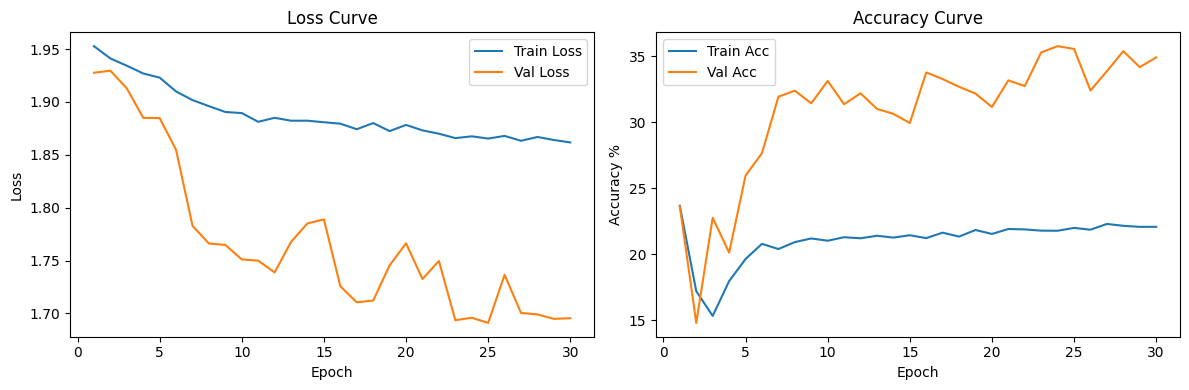

In [9]:
import matplotlib.pyplot as plt

# Paste your actual numbers from the terminal output
# Example — replace with your real numbers
epochs = list(range(1, 31))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"],   label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

In [34]:
import torch
import torch.nn as nn
from torchvision import models

class EmotionResNet(nn.Module):
    def __init__(self, num_classes=7, dropout=0.4):
        super(EmotionResNet, self).__init__()

        # Load pretrained ResNet18 (smallest, fastest ResNet)
        # pretrained weights from ImageNet
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # --- Fix 1: Change first conv layer to accept 1 channel instead of 3 ---
        # Original: Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        # New:      Conv2d(1, 64, kernel_size=7, stride=2, padding=3)
        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(
            1,                          # 1 input channel (grayscale)
            original_conv.out_channels, # keep 64 output channels
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=False
        )

        # Smart weight initialization:
        # Average the 3 RGB channel weights into 1 grayscale channel
        # Better than random initialization — keeps pretrained knowledge
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(
                original_conv.weight.mean(dim=1, keepdim=True)
            )

        # --- Fix 2: Replace final classifier head ---
        # Original ResNet head: Linear(512 → 1000) for ImageNet
        # Our head: Linear(512 → 7) for emotions
        in_features = self.resnet.fc.in_features  # 512 for ResNet18
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

        # --- Phase 1: Freeze everything except the head ---
        self.freeze_backbone()

    def freeze_backbone(self):
        """Freeze all layers except the final classifier head"""
        for name, param in self.resnet.named_parameters():
            if "fc" not in name:        # fc = our custom head
                param.requires_grad = False
        print("Backbone frozen — only training head")

    def unfreeze_last_blocks(self):
        """Phase 2: Unfreeze layer3, layer4 + head"""
        for name, param in self.resnet.named_parameters():
            if any(x in name for x in ["layer3", "layer4", "fc"]):
                param.requires_grad = True
        print("Unfroze layer3, layer4 + head")

    def unfreeze_all(self):
        """Phase 3: Unfreeze everything"""
        for param in self.resnet.parameters():
            param.requires_grad = True
        print("Unfroze entire network")

    def count_trainable(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"Trainable: {trainable:,} / {total:,} parameters")

    def forward(self, x):
        return self.resnet(x)
    

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from torchvision import transforms

DEVICE    = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
SAVE_PATH = "models/best_resnet.pth"

print(f"Training on: {DEVICE}")

# --- ResNet needs 224×224 images ---
resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

resnet_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# --- Dataset ---
train_dataset = FERDataset("data", split="train", transform=resnet_train_transform)
test_dataset  = FERDataset("data", split="test",  transform=resnet_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

# --- Class weights ---
samples_per_class = np.array([3995, 436, 4097, 7215, 4965, 4830, 3171])
total    = samples_per_class.sum()
weights  = total / (7 * samples_per_class)
weights  = torch.FloatTensor(weights).to(DEVICE)

# --- Model ---
model     = EmotionResNet(num_classes=7).to(DEVICE)
model.count_trainable()   # should show only ~500k trainable (just the head)

criterion = nn.CrossEntropyLoss(weight=weights)

# ============================================================
# TRAINING FUNCTION
# ============================================================
def run_epoch(model, loader, criterion, optimizer, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total * 100


# ============================================================
# PHASE 1 — Train head only (5 epochs, high LR)
# ============================================================
print("\n" + "="*50)
print("PHASE 1: Training head only")
print("="*50)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

best_acc = 0
for epoch in range(1, 6):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    val_loss,   val_acc   = run_epoch(model, test_loader,  criterion, optimizer, train=False)
    print(f"Epoch {epoch}/5 | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ✅ Saved! Best: {best_acc:.2f}%")


# ============================================================
# PHASE 2 — Unfreeze layer3, layer4 (10 epochs, lower LR)
# ============================================================
print("\n" + "="*50)
print("PHASE 2: Unfreezing layer3 + layer4")
print("="*50)

model.unfreeze_last_blocks()
model.count_trainable()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001    # 10x lower — careful not to destroy pretrained weights
)

for epoch in range(1, 11):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    val_loss,   val_acc   = run_epoch(model, test_loader,  criterion, optimizer, train=False)
    print(f"Epoch {epoch}/10 | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ✅ Saved! Best: {best_acc:.2f}%")


# ============================================================
# PHASE 3 — Unfreeze all (10 epochs, very low LR)
# ============================================================
print("\n" + "="*50)
print("PHASE 3: Full fine-tuning")
print("="*50)

model.unfreeze_all()
model.count_trainable()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.00001   # very low — gentle fine-tuning
)

for epoch in range(1, 11):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    val_loss,   val_acc   = run_epoch(model, test_loader,  criterion, optimizer, train=False)
    print(f"Epoch {epoch}/10 | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ✅ Saved! Best: {best_acc:.2f}%")

print(f"\n🏆 Training complete! Best Val Accuracy: {best_acc:.2f}%")

Training on: mps
[train] Loaded 28709 images
[test] Loaded 7178 images
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/makhmud.lp/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 28.1MB/s]


Backbone frozen — only training head
Trainable: 133,127 / 11,303,367 parameters

PHASE 1: Training head only
Epoch 1/5 | Train Acc: 29.93% | Val Acc: 35.40%
  ✅ Saved! Best: 35.40%
Epoch 2/5 | Train Acc: 33.06% | Val Acc: 39.82%
  ✅ Saved! Best: 39.82%
Epoch 3/5 | Train Acc: 34.23% | Val Acc: 40.05%
  ✅ Saved! Best: 40.05%
Epoch 4/5 | Train Acc: 34.82% | Val Acc: 41.07%
  ✅ Saved! Best: 41.07%
Epoch 5/5 | Train Acc: 35.62% | Val Acc: 40.74%

PHASE 2: Unfreezing layer3 + layer4
Unfroze layer3, layer4 + head
Trainable: 10,626,567 / 11,303,367 parameters
Epoch 1/10 | Train Acc: 49.08% | Val Acc: 56.52%
  ✅ Saved! Best: 56.52%
Epoch 2/10 | Train Acc: 56.70% | Val Acc: 59.01%
  ✅ Saved! Best: 59.01%
Epoch 3/10 | Train Acc: 60.99% | Val Acc: 62.43%
  ✅ Saved! Best: 62.43%
Epoch 4/10 | Train Acc: 63.47% | Val Acc: 61.70%
Epoch 5/10 | Train Acc: 65.87% | Val Acc: 63.19%
  ✅ Saved! Best: 63.19%
Epoch 6/10 | Train Acc: 67.90% | Val Acc: 63.62%
  ✅ Saved! Best: 63.62%
Epoch 7/10 | Train Acc: 70.2

In [ ]:
import torch
import cv2
import numpy as np
import mediapipe as mp
from collections import deque
from torchvision import transforms
from PIL import Image

# ============================================================
# CONFIG
# ============================================================
DEVICE     = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
MODEL_PATH = "models/best_resnet.pth"
EMOTIONS   = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]
EMOJIS     = ["😠", "🤢", "😨", "😊", "😐", "😢", "😮"]
THRESHOLD  = 0.45
SMOOTH_N   = 8

EMOTION_COLORS = {
    "Angry":    (0, 0, 255),
    "Disgust":  (0, 140, 255),
    "Fear":     (128, 0, 128),
    "Happy":    (0, 255, 0),
    "Neutral":  (255, 255, 255),
    "Sad":      (255, 0, 0),
    "Surprise": (0, 255, 255),
}

# ============================================================
# LOAD MODEL
# ============================================================
model = EmotionResNet(num_classes=7)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("✅ Model loaded!")

# ============================================================
# TRANSFORM
# ============================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ============================================================
# MEDIAPIPE SETUP
# ============================================================
mp_face_mesh      = mp.solutions.face_mesh
mp_drawing        = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# ============================================================
# SMOOTHING STATE
# ============================================================
smooth_buffer   = deque(maxlen=SMOOTH_N)
current_emotion = "Neutral"
current_conf    = 0.0

# ============================================================
# HELPER — get face bounding box from landmarks
# ============================================================
def get_face_crop(frame, landmarks, padding=0.2):
    h, w = frame.shape[:2]

    xs = [lm.x * w for lm in landmarks]
    ys = [lm.y * h for lm in landmarks]

    x_min, x_max = int(min(xs)), int(max(xs))
    y_min, y_max = int(min(ys)), int(max(ys))

    pad_x = int((x_max - x_min) * padding)
    pad_y = int((y_max - y_min) * padding)

    x1 = max(0, x_min - pad_x)
    y1 = max(0, y_min - pad_y)
    x2 = min(w, x_max + pad_x)
    y2 = min(h, y_max + pad_y)

    return frame[y1:y2, x1:x2], (x1, y1, x2, y2)

# ============================================================
# DRAW EMOTION BAR CHART
# ============================================================
def draw_emotion_bars(frame, probs, x, y):
    bar_width  = 120
    bar_height = 13
    padding    = 4

    for i, (emotion, prob) in enumerate(zip(EMOTIONS, probs)):
        bar_y = y + i * (bar_height + padding)
        color = EMOTION_COLORS[emotion]

        # Background
        cv2.rectangle(frame,
                      (x, bar_y),
                      (x + bar_width, bar_y + bar_height),
                      (50, 50, 50), -1)

        # Filled bar
        filled = int(prob * bar_width)
        cv2.rectangle(frame,
                      (x, bar_y),
                      (x + filled, bar_y + bar_height),
                      color, -1)

        # Label
        cv2.putText(frame,
                    f"{emotion[:3]}: {prob*100:.0f}%",
                    (x + bar_width + 5, bar_y + bar_height - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, color, 1)

# ============================================================
# PREDICT EMOTION
# ============================================================
def predict_emotion(face_crop):
    face_gray = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)
    pil_img   = Image.fromarray(face_gray)
    tensor    = transform(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(tensor)
        probs   = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    # Smooth
    smooth_buffer.append(probs)
    smoothed = np.mean(smooth_buffer, axis=0)

    return smoothed

# ============================================================
# MAIN WEBCAM LOOP
# ============================================================
def run_webcam():
    global current_emotion, current_conf

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not open webcam")
        return

    print("📷 Webcam started! Press 'q' to quit")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # OpenCV gives BGR — MediaPipe needs RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results   = face_mesh.process(frame_rgb)

        if results.multi_face_landmarks:
            face_landmarks = results.multi_face_landmarks[0]

            # --- Draw face mesh ---
            mp_drawing.draw_landmarks(
                image=frame,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_drawing_styles
                    .get_default_face_mesh_tesselation_style()
            )
            mp_drawing.draw_landmarks(
                image=frame,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_CONTOURS,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_drawing_styles
                    .get_default_face_mesh_contours_style()
            )

            # --- Crop + predict ---
            face_crop, (x1, y1, x2, y2) = get_face_crop(
                frame, face_landmarks.landmark
            )

            if face_crop.size > 0:
                smoothed = predict_emotion(face_crop)

                top_idx    = smoothed.argmax()
                confidence = smoothed[top_idx]

                # Only update if confident enough
                if confidence >= THRESHOLD:
                    current_emotion = EMOTIONS[top_idx]
                    current_conf    = confidence

                color = EMOTION_COLORS[current_emotion]

                # Emotion label top left
                cv2.rectangle(frame, (0, 0), (340, 45), (0, 0, 0), -1)
                cv2.putText(
                    frame,
                    f"Emotion: {current_emotion} {current_conf*100:.0f}%",
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2
                )

                # Probability bars — bottom left
                h = frame.shape[0]
                draw_emotion_bars(frame, smoothed, 10, h - 140)

        else:
            smooth_buffer.clear()
            cv2.putText(frame, "No face detected", (20, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

        cv2.putText(frame, "Press 'q' to quit", (10, frame.shape[0] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150, 150, 150), 1)

        cv2.imshow("Emotion Recognition", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    face_mesh.close()
    print("👋 Webcam closed")


if __name__ == "__main__":
    run_webcam()

Backbone frozen — only training head
✅ Model loaded!


AttributeError: module 'mediapipe' has no attribute 'solutions'

: 

In [35]:
import torch
import torch.nn as nn
import cv2
import numpy as np
from torchvision import transforms
from PIL import Image

# ============================================================
# CONFIG
# ============================================================
DEVICE     = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
MODEL_PATH = "models/best_resnet.pth"

EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

EMOTION_COLORS = {
    "Angry":    (0, 0, 255),      # Red
    "Disgust":  (0, 140, 255),    # Orange
    "Fear":     (128, 0, 128),    # Purple
    "Happy":    (0, 255, 0),      # Green
    "Neutral":  (255, 255, 255),  # White
    "Sad":      (255, 0, 0),      # Blue
    "Surprise": (0, 255, 255),    # Yellow
}

# ============================================================
# LOAD MODEL
# ============================================================
model = EmotionResNet(num_classes=7)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()   # crucial — turns off dropout
print("✅ Model loaded!")

# ============================================================
# TRANSFORM — same as training (no augmentation)
# ============================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ============================================================
# FACE DETECTOR — OpenCV Haar Cascade
# ============================================================
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# ============================================================
# PREDICT EMOTION FOR ONE FACE
# ============================================================
def predict_emotion(face_img):
    """
    face_img: numpy array (cropped face from webcam, BGR)
    returns: emotion string, confidence float, all probs list
    """
    # Convert BGR (OpenCV) → Grayscale → PIL Image
    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    pil_img = Image.fromarray(gray)

    # Apply transforms
    tensor = transform(pil_img).unsqueeze(0).to(DEVICE)  # add batch dim

    # Inference
    with torch.no_grad():
        outputs = model(tensor)
        probs   = torch.softmax(outputs, dim=1)[0]  # convert to probabilities

    # Get top prediction
    confidence, predicted_idx = probs.max(0)
    emotion = EMOTIONS[predicted_idx.item()]

    return emotion, confidence.item(), probs.cpu().numpy()


# ============================================================
# DRAW EMOTION BAR CHART ON FRAME
# ============================================================
def draw_emotion_bars(frame, probs, x, y):
    """Draw a small bar chart showing all emotion probabilities"""
    bar_width = 100
    bar_height = 12
    padding = 3

    for i, (emotion, prob) in enumerate(zip(EMOTIONS, probs)):
        bar_y = y + i * (bar_height + padding)

        # Background bar
        cv2.rectangle(frame,
                      (x, bar_y),
                      (x + bar_width, bar_y + bar_height),
                      (50, 50, 50), -1)

        # Filled bar (proportional to probability)
        filled = int(prob * bar_width)
        color  = EMOTION_COLORS[emotion]
        cv2.rectangle(frame,
                      (x, bar_y),
                      (x + filled, bar_y + bar_height),
                      color, -1)

        # Label + percentage
        cv2.putText(frame,
                    f"{emotion[:3]}: {prob*100:.0f}%",
                    (x + bar_width + 5, bar_y + bar_height - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)


# ============================================================
# MAIN WEBCAM LOOP
# ============================================================
def run_webcam():
    cap = cv2.VideoCapture(0)  # 0 = default webcam

    if not cap.isOpened():
        print("Error: Could not open webcam")
        return

    print("📷 Webcam started! Press 'q' to quit")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to grayscale for face detection
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,   # how much image size is reduced at each scale
            minNeighbors=5,    # how many neighbors each rectangle should have
            minSize=(48, 48)   # minimum face size to detect
        )

        for (x, y, w, h) in faces:
            # Crop face from frame
            face_crop = frame[y:y+h, x:x+w]

            # Skip if crop is too small
            if face_crop.size == 0:
                continue

            # Predict emotion
            emotion, confidence, probs = predict_emotion(face_crop)
            color = EMOTION_COLORS[emotion]

            # Draw face rectangle
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)

            # Draw emotion label above face
            label = f"{emotion} {confidence*100:.0f}%"
            label_y = y - 10 if y - 10 > 10 else y + h + 20
            cv2.putText(frame, label, (x, label_y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

            # Draw probability bars next to face
            bars_x = x + w + 10
            bars_y = y
            if bars_x + 160 < frame.shape[1]:  # make sure it fits on screen
                draw_emotion_bars(frame, probs, bars_x, bars_y)

        # Show FPS hint
        cv2.putText(frame, "Press 'q' to quit", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)

        cv2.imshow("Emotion Recognition", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("👋 Webcam closed")


if __name__ == "__main__":
    run_webcam()

Backbone frozen — only training head
✅ Model loaded!
📷 Webcam started! Press 'q' to quit
👋 Webcam closed


In [2]:
%pip install gradio


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
!which python

/Users/makhmud.lp/Codes All/torch-env/bin/python


In [9]:
!grep "class EmotionResNet" models/resnet.py
# Should print: class EmotionResNet(nn.Module):

In [10]:
!ls models/


__init__.py     best_model.pth  cnn.py
__pycache__     best_resnet.pth resnet.py


In [8]:
!touch models/__init__.py

In [22]:
!cat app.py

import torch
import gradio as gr
import numpy as np
import cv2
from torchvision import transforms
from PIL import Image
from models.resnet import EmotionResNet
from collections import deque

# ============================================================
# CONFIG
# ============================================================
DEVICE     = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
MODEL_PATH = "models/best_resnet.pth"
EMOTIONS   = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

EMOTION_EMOJIS = {
    "Angry":    "😠",
    "Disgust":  "🤢",
    "Fear":     "😨",
    "Happy":    "😊",
    "Neutral":  "😐",
    "Sad":      "😢",
    "Surprise": "😮",
}
smooth_buffer = deque(maxlen=100)

# ============================================================
# LOAD MODEL
# ============================================================
model = EmotionResNet(num_classes=7)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval

In [25]:
%pip install mediapipe

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 4.3 MB/s  0:00:04 eta 0:00:01
Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 MB 3.8 MB/s  0:00:13m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [mediapipe]/7 [mediapipe]trib-python]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
!python3 app.py

Backbone frozen — only training head
✅ Model loaded on mps
Traceback (most recent call last):
  File "/Users/makhmud.lp/Codes All/ComputerVisionProjects/face-emotion-recognition/app.py", line 42, in <module>
    mp_face_mesh    = mp.solutions.face_mesh
                      ^^^^^^^^^^^^
AttributeError: module 'mediapipe' has no attribute 'solutions'


In [ ]:
import mediapipe
print(mediapipe.__version__)

0.10.32


In [30]:
%pip install mediapipe==0.10.9 --force-reinstall

  Using cached mediapipe-0.10.9-cp311-cp311-macosx_11_0_universal2.whl.metadata (9.6 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached numpy-2.4.2-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
  Using cached sounddevice-0.5.5-py3-none-macosx_10_6_x86_64.macosx_10_6_universal2.whl.metadata (1.4 kB)
  Using cached cffi-2.0.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.6 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.m

In [32]:
!python3 app.py

Backbone frozen — only training head
✅ Model loaded on mps
I0000 00:00:1772804079.646825       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
^C
Traceback (most recent call last):
  File "/Users/makhmud.lp/Codes All/torch-env/lib/python3.11/site-packages/gradio/blocks.py", line 3071, in block_thread
    time.sleep(0.1)
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/makhmud.lp/Codes All/ComputerVisionProjects/face-emotion-recognition/app.py", line 234, in <module>
    demo.launch()
  File "/Users/makhmud.lp/Codes All/torch-env/lib/python3.11/site-packages/gradio/blocks.py", line 2978, in launch
    self.block_thread()
  File "/Users/makhmud.lp/Codes All/torch-env/lib/python3.11/site-packages/gradio/blocks.py",